In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import requests
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("STEAM_API_KEY")

BASE = "https://api.steampowered.com"

# Inicialização (normalmente exige uma Steam API Key)
def get_friends(steam_id):

    url = f"{BASE}/ISteamUser/GetFriendList/v1/"

    params = {
        "key": API_KEY,
        "steamid": steam_id,
        "relationship": "friend"
    }

    r = requests.get(url, params=params)

    if r.status_code != 200:
        return []

    data = r.json()

    if "friendslist" not in data:
        return []

    return [f["steamid"] for f in data["friendslist"]["friends"]]


def construir_grafo_social(steam_id_raiz, profundidade_maxima=1):
    G = nx.Graph()
    
    # Fila de processamento: tupla de (steam_id, profundidade_atual)
    fila = [(steam_id_raiz, 0)]
    visitados = set()
    
    while fila:
        atual_id, nivel = fila.pop(0)
        
        if atual_id in visitados or nivel > profundidade_maxima:
            continue
            
        visitados.add(atual_id)
        
        try:
            # Método hipotético da sua lib para pegar a lista de amigos
            amigos = get_friends(atual_id) 
            
            for amigo_id in amigos:
                # Adiciona o vínculo de amizade no grafo
                G.add_edge(atual_id, amigo_id)
                
                # Se ainda não atingimos o limite de profundidade, adicionamos na fila
                if nivel < profundidade_maxima:
                    fila.append((amigo_id, nivel + 1))
                    
        except Exception as e:
            print(f"Erro ao buscar dados do ID {atual_id}: {e}")
            
    return G

# Criando a rede a partir de um jogador
meu_steam_id = "76561198320338168"
grafo_steam = construir_grafo_social(meu_steam_id, profundidade_maxima=2)

In [2]:
# 1. Análise Macro: Qual o tamanho da nossa rede?
print("=== ESTATÍSTICAS GERAIS ===")
print(f"Total de Jogadores na rede: {grafo_steam.number_of_nodes()}")
print(f"Total de Amizades mapeadas: {grafo_steam.number_of_edges()}")

# 2. Centralidade de Grau (Degree Centrality): Quem são os "Hubs"?
# Isso revela quem são os jogadores mais conectados e influentes dentro dessa bolha.
centralidade = nx.degree_centrality(grafo_steam)
top_influencers = sorted(centralidade.items(), key=lambda x: x[1], reverse=True)[:5]

print("\n=== TOP 5 JOGADORES MAIS CONECTADOS ===")
for node, score in top_influencers:
    # Multiplicamos por 100 para ver como porcentagem de conexão na rede
    print(f"Steam ID {node}: Conectado a {score * 100:.1f}% da rede")

# 3. Detecção de Comunidades (Clustering): Quais são os "esquadrões"?
# Divide o grafo em grupos onde os jogadores jogam/são muito amigos entre si.
from networkx.algorithms.community import greedy_modularity_communities

comunidades = greedy_modularity_communities(grafo_steam)
print(f"\n=== COMUNIDADES DETECTADAS ===")
print(f"Foram identificados {len(comunidades)} grupos isolados ou sub-bolhas.")

for i, comunidade in enumerate(comunidades[:3]): # Mostrando os 3 maiores grupos
    print(f"Grupo {i+1}: {len(comunidade)} membros")

=== ESTATÍSTICAS GERAIS ===
Total de Jogadores na rede: 793
Total de Amizades mapeadas: 907

=== TOP 5 JOGADORES MAIS CONECTADOS ===
Steam ID 76561198400024070: Conectado a 25.9% da rede
Steam ID 76561198408714684: Conectado a 19.8% da rede
Steam ID 76561198285534477: Conectado a 16.4% da rede
Steam ID 76561198103820259: Conectado a 10.1% da rede
Steam ID 76561198397177352: Conectado a 9.3% da rede

=== COMUNIDADES DETECTADAS ===
Foram identificados 8 grupos isolados ou sub-bolhas.
Grupo 1: 178 membros
Grupo 2: 145 membros
Grupo 3: 130 membros


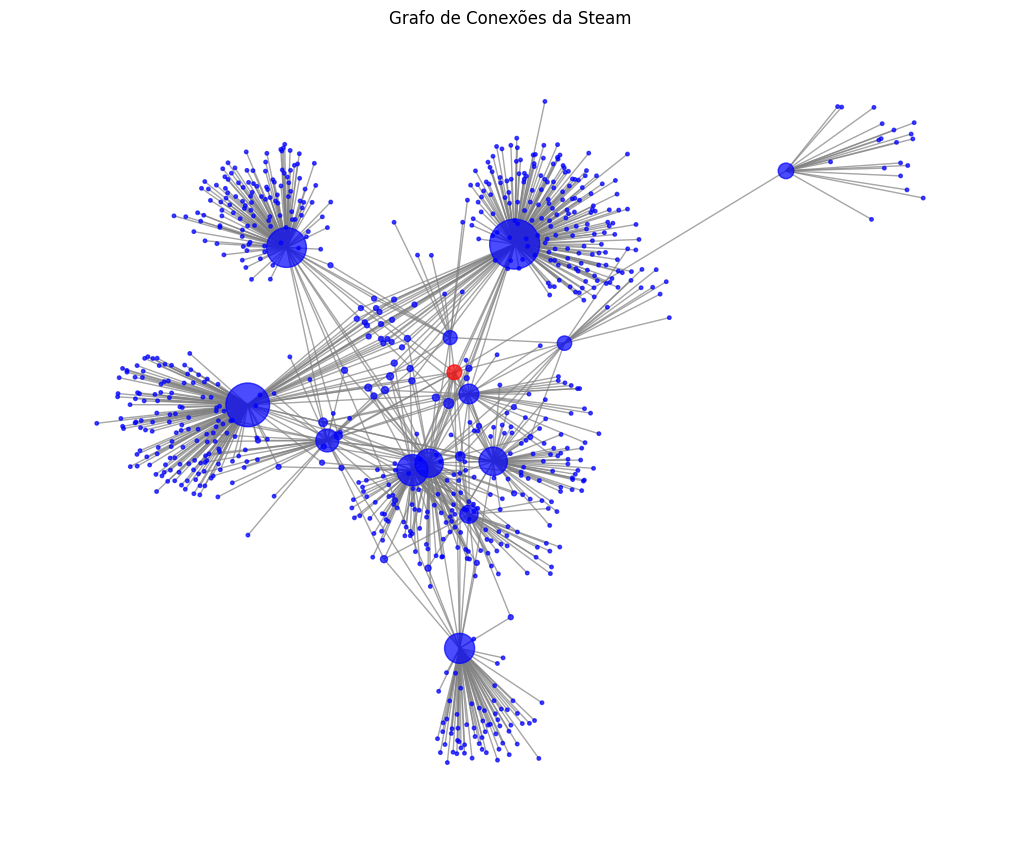

In [3]:
# Mapeia as cores: Vermelho para o jogador raiz, Azul para os demais
cores = ["red" if node == meu_steam_id else "blue" for node in grafo_steam.nodes()]

# Define o tamanho dos nós baseado na influência (centralidade) deles
tamanhos = [centralidade[node] * 5000 for node in grafo_steam.nodes()]

plt.figure(figsize=(10, 8))
nx.draw(
    grafo_steam, 
    node_color=cores, 
    node_size=tamanhos, 
    with_labels=False, 
    alpha=0.7, 
    edge_color="gray"
)
plt.title("Grafo de Conexões da Steam")
plt.show()

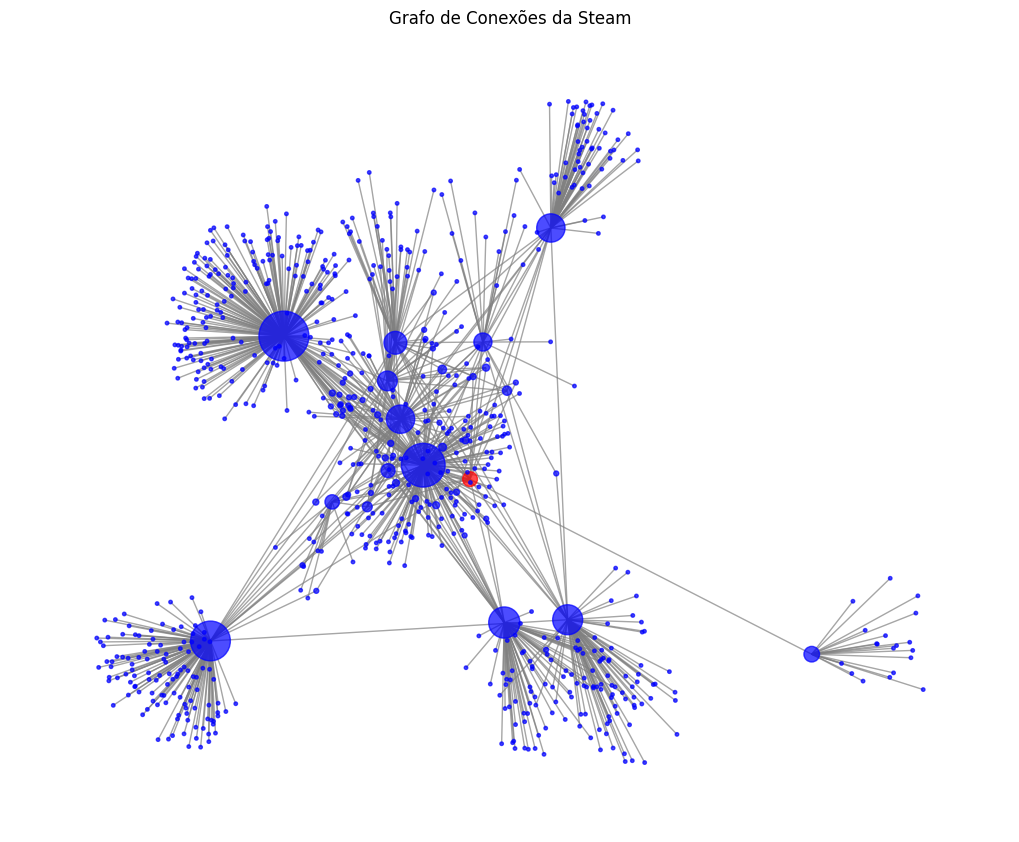

In [4]:
# Mapeia as cores: Vermelho para o jogador raiz, Azul para os demais
cores = ["red" if node == meu_steam_id else "blue" for node in grafo_steam.nodes()]

# Define o tamanho dos nós baseado na influência (centralidade) deles
tamanhos = [centralidade[node] * 5000 for node in grafo_steam.nodes()]

plt.figure(figsize=(10, 8))
nx.draw(
    grafo_steam, 
    node_color=cores, 
    node_size=tamanhos, 
    with_labels=False, 
    alpha=0.7, 
    edge_color="gray"
)
plt.title("Grafo de Conexões da Steam")
plt.show()